<a href="https://colab.research.google.com/github/chindarkarsejal800-dot/CSL701-08_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:SejalRavindra Chindarkar
RolNo:CS08

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [2]:
# Task 1: Environment Setup and Dataset Acquisition

# Import necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import sklearn
import sklearn

# Column headers for the Pima Indians Diabetes dataset
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Download the dataset if not present
# The file is not found, so we'll download it from a common source.
!wget -nc https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv -O pima-indians-diabetes.data

# Load the dataset
# Make sure 'pima-indians-diabetes.data' is in your current working directory
df = pd.read_csv(
    'pima-indians-diabetes.data',
    header=None,
    names=columns
)

# 1. Print the first five records
print("First five records of the dataset:")
print(df.head())

# 2. Print the dataset shape
print("\nDataset shape:")
print(df.shape)

# 3. Print data types of all features
print("\nData types of all features:")
print(df.dtypes)

# 4. Print descriptive statistics of numeric features
print("\nDescriptive statistics of numeric features:")
print(df.describe())

--2026-09-01 05:12:45--  https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23278 (23K) [text/plain]
Saving to: ‘pima-indians-diabetes.data’

pima-indians-diabet 100%[===================>]  22.73K  --.-KB/s    in 0.003s  

2026-09-01 05:12:45 (7.43 MB/s) - ‘pima-indians-diabetes.data’ saved [23278/23278]

First five records of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66            

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Non-diabetic (0): 500
Diabetic (1):     268

Class Percentages:
Non-diabetic (0): 65.10%
Diabetic (1):     34.90%


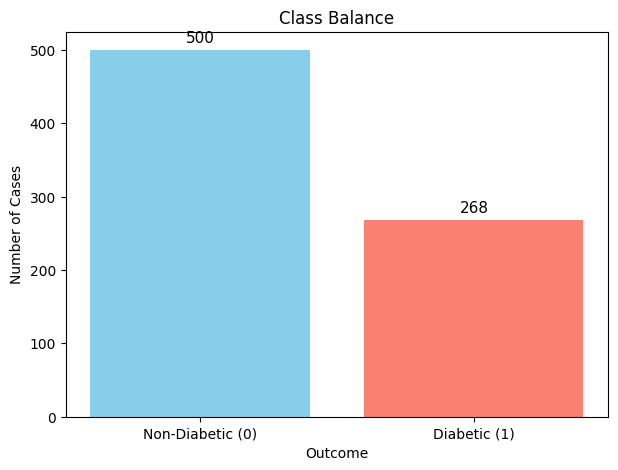

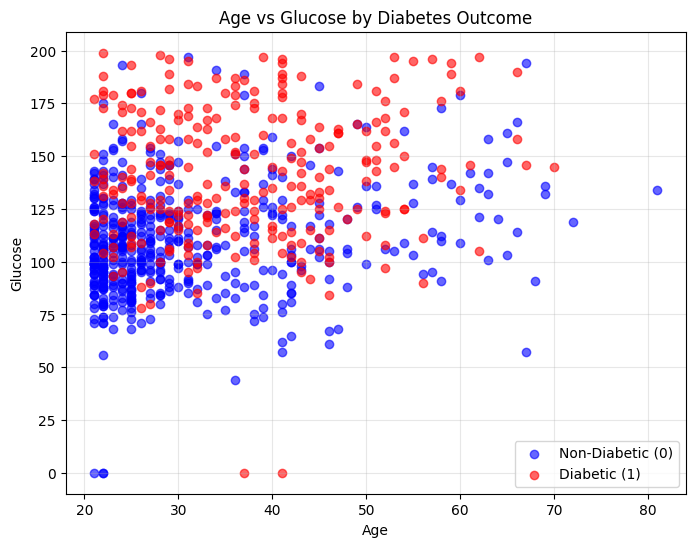

In [3]:
# Task 2: Exploratory Data Analysis (EDA)

# --------------------------------------------------
# 1. Class balance: Count and percentage
# --------------------------------------------------

# Calculate absolute counts
class_counts = df['Outcome'].value_counts().sort_index()

# Calculate percentages
class_percentages = df['Outcome'].value_counts(normalize=True).sort_index() * 100

print("Class Counts:")
print(f"Non-diabetic (0): {class_counts[0]}")
print(f"Diabetic (1):     {class_counts[1]}")

print("\nClass Percentages:")
print(f"Non-diabetic (0): {class_percentages[0]:.2f}%")
print(f"Diabetic (1):     {class_percentages[1]:.2f}%")


# --------------------------------------------------
# 2. Plot class balance using a bar chart
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    [class_counts[0], class_counts[1]],
    color=['skyblue', 'salmon']
)

plt.title('Class Balance')
plt.xlabel('Outcome')
plt.ylabel('Number of Cases')

# Display count on top of each bar
for i, count in enumerate([class_counts[0], class_counts[1]]):
    plt.text(i, count + 10, str(count), ha='center', fontsize=11)

plt.show()


# --------------------------------------------------
# 3. Scatter plot: Age vs Glucose
# --------------------------------------------------

plt.figure(figsize=(8, 6))

# Plot non-diabetic cases
plt.scatter(
    df[df['Outcome'] == 0]['Age'],
    df[df['Outcome'] == 0]['Glucose'],
    color='blue',
    label='Non-Diabetic (0)',
    alpha=0.6
)

# Plot diabetic cases
plt.scatter(
    df[df['Outcome'] == 1]['Age'],
    df[df['Outcome'] == 1]['Glucose'],
    color='red',
    label='Diabetic (1)',
    alpha=0.6
)

plt.title('Age vs Glucose by Diabetes Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [4]:
# Task 3: Preprocessing and Handling Missing Values

# Features where 0 is physically impossible
invalid_zero_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# --------------------------------------------------
# 1. Replace invalid 0 values with NaN
# --------------------------------------------------

df[invalid_zero_features] = df[invalid_zero_features].replace(0, np.nan)

print("Missing values after replacing 0 with NaN:")
print(df[invalid_zero_features].isnull().sum())


# --------------------------------------------------
# 2. Impute missing values using the median
# --------------------------------------------------

for feature in invalid_zero_features:
    df[feature] = df[feature].fillna(df[feature].median())


# --------------------------------------------------
# 3. Check that there are no missing values remaining
# --------------------------------------------------

print("\nMissing values after median imputation:")
print(df.isnull().sum())


# --------------------------------------------------
# 4. Check the first five records
# --------------------------------------------------

print("\nFirst five records after preprocessing:")
print(df.head())


# --------------------------------------------------
# 5. Verify data types
# --------------------------------------------------

print("\nData types after preprocessing:")
print(df.dtypes)


Missing values after replacing 0 with NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

First five records after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [5]:
# Task 4: Stratified Train-Test Splitting

from sklearn.model_selection import train_test_split

# --------------------------------------------------
# 1. Isolate feature matrix (X) and target vector (y)
# --------------------------------------------------

# X = first 8 columns (features)
X = df.iloc[:, :8]

# y = 9th column (target)
y = df.iloc[:, 8]


# --------------------------------------------------
# 2. Split data into 80% training and 20% testing
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# 3. Display the shapes
# --------------------------------------------------

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


# --------------------------------------------------
# 4. Check class proportions
# --------------------------------------------------

print("\nClass distribution in original dataset:")
print(y.value_counts(normalize=True) * 100)

print("\nClass distribution in training dataset:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in test dataset:")
print(y_test.value_counts(normalize=True) * 100)


Training feature shape: (614, 8)
Testing feature shape: (154, 8)
Training target shape: (614,)
Testing target shape: (154,)

Class distribution in original dataset:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Class distribution in training dataset:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Class distribution in test dataset:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [6]:
# Task 5: Custom Bootstrap Sampling Function

# --------------------------------------------------
# 1. Define the bootstrap sampling function
# --------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Generate a bootstrap sample from X and y using
    sampling with replacement.

    Parameters:
        X : Feature matrix
        y : Target vector

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        sample_indices : Indices selected for bootstrap sample
    """

    # Number of observations in the training set
    N = len(X)

    # Randomly select N indices with replacement
    sample_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[sample_indices].copy()
    y_bootstrap = y.iloc[sample_indices].copy()

    return X_bootstrap, y_bootstrap, sample_indices


# --------------------------------------------------
# 2. Generate a bootstrap sample
# --------------------------------------------------

X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# --------------------------------------------------
# 3. Verify the size of the bootstrap sample
# --------------------------------------------------

print("Original training set size:", len(X_train))
print("Bootstrap feature matrix size:", len(X_bootstrap))
print("Bootstrap target vector size:", len(y_bootstrap))


# --------------------------------------------------
# 4. Check for duplicated original row indices
# --------------------------------------------------

unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\nNumber of unique observations selected:",
      len(unique_indices))

print("Number of duplicated observations:",
      len(duplicated_indices))

print("\nSome duplicated row indices:")
print(duplicated_indices[:10])


# --------------------------------------------------
# 5. Identify Out-of-Bag (OOB) observations
# --------------------------------------------------

# All indices in the training dataset
all_indices = np.arange(len(X_train))

# Indices that were NOT selected in the bootstrap sample
oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("\nNumber of Out-of-Bag (OOB) observations:",
      len(oob_indices))

print("\nSome OOB row indices:")
print(oob_indices[:10])


Original training set size: 614
Bootstrap feature matrix size: 614
Bootstrap target vector size: 614

Number of unique observations selected: 376
Number of duplicated observations: 164

Some duplicated row indices:
[ 2 10 11 13 18 23 28 29 35 37]

Number of Out-of-Bag (OOB) observations: 238

Some OOB row indices:
[ 0  1  5  8  9 14 17 22 27 33]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [7]:
# Task 6: Growing the Ensemble of Base Classifiers

from sklearn.tree import DecisionTreeClassifier

# --------------------------------------------------
# 1. Initialize ensemble parameters
# --------------------------------------------------

B = 50  # Number of bootstrap iterations

# Empty list to store trained decision trees
ensemble = []


# --------------------------------------------------
# 2. Train B decision trees
# --------------------------------------------------

for b in range(B):

    # Generate a new bootstrap sample
    X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model on the bootstrap sample
    model.fit(X_bootstrap, y_bootstrap)

    # Add the trained model to the ensemble
    ensemble.append(model)


# --------------------------------------------------
# 3. Verify the ensemble
# --------------------------------------------------

print("Number of decision trees in the ensemble:", len(ensemble))

# Check the type of the first model
print("Type of first model:", type(ensemble[0]))

# Check the maximum depth of the first tree
print("Depth of first tree:", ensemble[0].get_depth())


Number of decision trees in the ensemble: 50
Type of first model: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Depth of first tree: 13


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [8]:
# Task 7: Custom Bagging Prediction using Majority Voting

def custom_bagging_predict(ensemble, X_test):
    """
    Generate predictions using majority voting
    across all decision trees in the ensemble.

    Parameters:
        ensemble : list
            List of trained decision tree classifiers.
        X_test : DataFrame
            Test feature matrix.

    Returns:
        final_predictions : NumPy array
            Majority-voted predictions (0 or 1).
    """

    # Collect predictions from every tree
    all_predictions = []

    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert list to NumPy array
    # Shape: (number_of_models, number_of_test_samples)
    all_predictions = np.array(all_predictions)

    # Majority voting
    final_predictions = []

    for i in range(X_test.shape[0]):

        # Predictions from all trees for sample i
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        votes_class_0 = np.sum(votes == 0)
        votes_class_1 = np.sum(votes == 1)

        # Select class with the highest number of votes
        if votes_class_1 > votes_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# --------------------------------------------------
# Generate final predictions
# --------------------------------------------------

y_pred = custom_bagging_predict(ensemble, X_test)


# --------------------------------------------------
# Verify the predictions
# --------------------------------------------------

print("Final predictions:")
print(y_pred)

print("\nNumber of test samples:", len(y_pred))

print("\nUnique predicted classes:")
print(np.unique(y_pred))


Final predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0
 1 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 1 0]

Number of test samples: 154

Unique predicted classes:
[0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

Confusion Matrix - Single Decision Tree:
[[79 21]
 [28 26]]

Confusion Matrix - Bagging:
[[83 17]
 [26 28]]

PERFORMANCE COMPARISON

Single Decision Tree:
Accuracy :  0.6818
Precision:  0.5532
Recall   :  0.4815
F1-Score :  0.5149

Bagging Ensemble:
Accuracy :  0.7208
Precision:  0.6222
Recall   :  0.5185
F1-Score :  0.5657


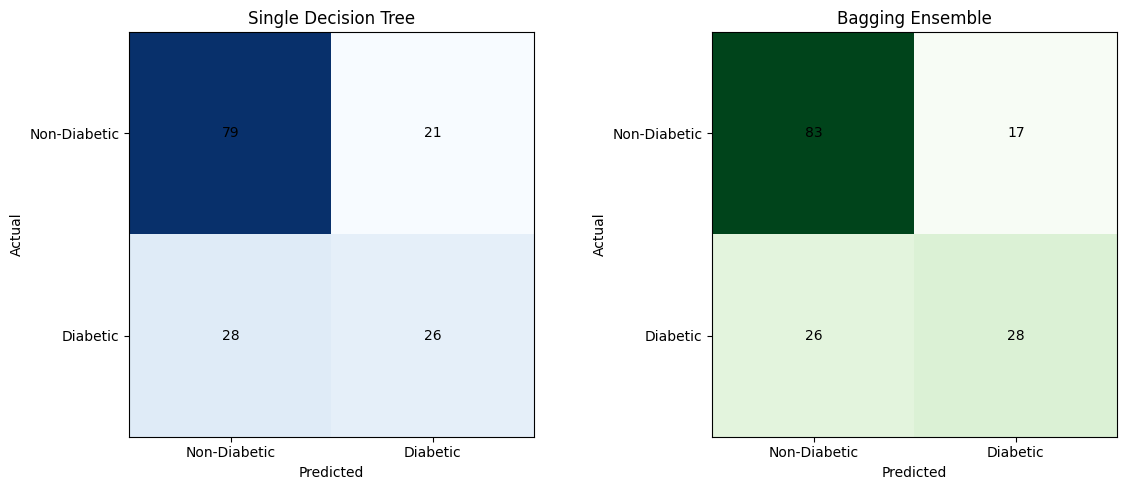

In [9]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Train a single fully grown Decision Tree
# --------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on the original, non-resampled training data
single_tree.fit(X_train, y_train)


# --------------------------------------------------
# 2. Make predictions using the single tree
# --------------------------------------------------

y_pred_single = single_tree.predict(X_test)


# --------------------------------------------------
# 3. Make predictions using custom Bagging classifier
# --------------------------------------------------

y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)


# --------------------------------------------------
# 4. Construct confusion matrices
# --------------------------------------------------

cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("Confusion Matrix - Single Decision Tree:")
print(cm_single)

print("\nConfusion Matrix - Bagging:")
print(cm_bagging)


# --------------------------------------------------
# 5. Calculate performance metrics
# --------------------------------------------------

# Single Decision Tree
accuracy_single = accuracy_score(y_test, y_pred_single)
precision_single = precision_score(y_test, y_pred_single)
recall_single = recall_score(y_test, y_pred_single)
f1_single = f1_score(y_test, y_pred_single)


# Bagging
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)


# --------------------------------------------------
# 6. Print performance comparison
# --------------------------------------------------

print("\n" + "=" * 55)
print("PERFORMANCE COMPARISON")
print("=" * 55)

print("\nSingle Decision Tree:")
print(f"Accuracy :  {accuracy_single:.4f}")
print(f"Precision:  {precision_single:.4f}")
print(f"Recall   :  {recall_single:.4f}")
print(f"F1-Score :  {f1_single:.4f}")

print("\nBagging Ensemble:")
print(f"Accuracy :  {accuracy_bagging:.4f}")
print(f"Precision:  {precision_bagging:.4f}")
print(f"Recall   :  {recall_bagging:.4f}")
print(f"F1-Score :  {f1_bagging:.4f}")


# --------------------------------------------------
# 7. Display confusion matrices as plots
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Single Tree Confusion Matrix
axes[0].imshow(cm_single, cmap='Blues')
axes[0].set_title('Single Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Add values to the matrix
for i in range(2):
    for j in range(2):
        axes[0].text(
            j, i, cm_single[i, j],
            ha='center',
            va='center',
            color='black'
        )

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])
axes[0].set_yticklabels(['Non-Diabetic', 'Diabetic'])


# Bagging Confusion Matrix
axes[1].imshow(cm_bagging, cmap='Greens')
axes[1].set_title('Bagging Ensemble')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Add values to the matrix
for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, cm_bagging[i, j],
            ha='center',
            va='center',
            color='black'
        )

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Non-Diabetic', 'Diabetic'])
axes[1].set_yticklabels(['Non-Diabetic', 'Diabetic'])

plt.tight_layout()
plt.show()


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

ROC-AUC PERFORMANCE
Single Decision Tree AUC : 0.6357
Bagging Ensemble AUC     : 0.8012

AUC Improvement          : 0.1655


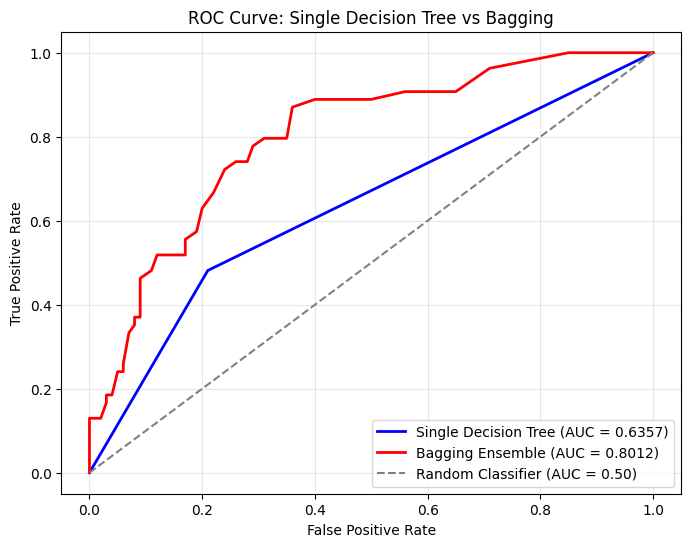

In [10]:
# Task 9: ROC-AUC Analysis and Curve Visualization

from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Predict probabilities using the single tree
# --------------------------------------------------

# Probability of class 1 (diabetic)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# --------------------------------------------------
# 2. Predict probabilities using the Bagging ensemble
# --------------------------------------------------

# Store probability predictions from all trees
all_probabilities = []

for model in ensemble:
    # Probability of class 1 from each tree
    prob = model.predict_proba(X_test)[:, 1]
    all_probabilities.append(prob)

# Convert to NumPy array
# Shape = (50 trees, 154 test samples)
all_probabilities = np.array(all_probabilities)

# Average probabilities across all 50 trees
y_prob_bagging = np.mean(all_probabilities, axis=0)


# --------------------------------------------------
# 3. Calculate ROC curves
# --------------------------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# --------------------------------------------------
# 4. Calculate AUC
# --------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# --------------------------------------------------
# 5. Print AUC results
# --------------------------------------------------

print("=" * 50)
print("ROC-AUC PERFORMANCE")
print("=" * 50)

print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Bagging Ensemble AUC     : {auc_bagging:.4f}")

print(f"\nAUC Improvement          : {auc_bagging - auc_single:.4f}")


# --------------------------------------------------
# 6. Plot ROC curves
# --------------------------------------------------

plt.figure(figsize=(8, 6))

# Single Decision Tree ROC
plt.plot(
    fpr_single,
    tpr_single,
    color='blue',
    linewidth=2,
    label=f'Single Decision Tree (AUC = {auc_single:.4f})'
)

# Bagging ROC
plt.plot(
    fpr_bagging,
    tpr_bagging,
    color='red',
    linewidth=2,
    label=f'Bagging Ensemble (AUC = {auc_bagging:.4f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    color='gray',
    linestyle='--',
    label='Random Classifier (AUC = 0.50)'
)

plt.title('ROC Curve: Single Decision Tree vs Bagging')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()


#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [11]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)
import numpy as np


# --------------------------------------------------
# 1. Create the base Decision Tree
# --------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


# --------------------------------------------------
# 2. Create Scikit-Learn BaggingClassifier
# --------------------------------------------------

sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)


# --------------------------------------------------
# 3. Train the BaggingClassifier
# --------------------------------------------------

sklearn_bagging.fit(X_train, y_train)


# --------------------------------------------------
# 4. Make predictions
# --------------------------------------------------

y_pred_sklearn = sklearn_bagging.predict(X_test)


# --------------------------------------------------
# 5. Calculate accuracy
# --------------------------------------------------

accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)


# --------------------------------------------------
# 6. Calculate confusion matrix
# --------------------------------------------------

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


print("=" * 60)
print("SCIKIT-LEARN BAGGING CLASSIFIER")
print("=" * 60)

print("\nTest Accuracy:")
print(f"{accuracy_sklearn:.4f}")

print("\nConfusion Matrix:")
print(cm_sklearn)


SCIKIT-LEARN BAGGING CLASSIFIER

Test Accuracy:
0.7338

Confusion Matrix:
[[85 15]
 [26 28]]


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?